<a href="https://colab.research.google.com/github/Vaib-raksh/Intern-ML/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Vaib-raksh/Intern-ML/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

### Research question

Can search-performance features, particularly search position and impressions, provide useful directional signals for page-level click-through rate (CTR)?

### Decision supported

The goal is to identify pages that may be worth reviewing or optimizing based on their observed search-performance signals.

This is a decision-support problem rather than an attempt to build a fully automated CTR prediction system. The analysis compares a simple baseline with a Random Forest regression model and tests whether the model provides additional predictive value under an honest time-aware evaluation.

The final output is a ranked, human-reviewed content action queue.

## 2. Data

This analysis uses the FlyRank Internship — Pseudonymized Warehouse Release (v20260703).

The analysis uses the `fact_content_daily_performance` table at the daily content-performance level.

For the modeling workflow, I used a time-ordered window from January through June 2026:
- Training: January 1, 2026 to April 30, 2026
- Validation: May 1, 2026 to May 31, 2026
- Test: June 1, 2026 to June 30, 2026

Rows with zero GSC impressions were excluded because CTR is defined as clicks divided by impressions, so these rows do not provide a usable CTR observation.

The analysis uses pseudonymized identifiers and does not expose client names, URLs, or private search queries.

In [17]:
!pip install -q huggingface_hub

In [18]:
from huggingface_hub import login

login()

In [19]:
import os
os.environ["HF_TOKEN"] = "YOUR_HUGGINGFACE_TOKEN"

In [20]:
import duckdb
import pandas as pd
import numpy as np

from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

print("Token loaded:", HF_TOKEN is not None)

Token loaded: True


In [21]:
con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET huggingface_secret (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
);
""")

print("Connected successfully!")

Connected successfully!


In [22]:
print(con.sql("FROM duckdb_secrets()").df())

                 name         type provider  persistent storage    scope  \
0  huggingface_secret  huggingface   config       False  memory  [hf://]   

                                       secret_string  
0  name=huggingface_secret;type=huggingface;provi...  


In [23]:
DATASET = "hf://datasets/FlyRank/internship-warehouse"

test_connection = con.sql(f"""
SELECT *
FROM read_parquet(
    '{DATASET}/fact_content_daily_performance/month=2026-03/*.parquet'
)
LIMIT 5
""").df()

print(test_connection.shape)
test_connection.head()

(5, 31)


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,<NA>,20,0,67,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,<NA>,1,0,0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,<NA>,125,1,616,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,<NA>,7,0,28,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,<NA>,11,0,25,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03


In [24]:
# Read the HF_TOKEN from colab
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")
print("Token loaded successfully!" if HF_TOKEN else "Token not found")

#connect DuckDB to Hugging face
import duckdb

con = duckdb.connect()

con.execute(f"""
CREATE SECRET (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
);
""")

print("Connected successfully!")

Token loaded successfully!
Connected successfully!


In [25]:
DATASET = "hf://datasets/FlyRank/internship-warehouse" # the dataset path

In [26]:
january_test = con.sql(f"""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_sum_position,
    client_has_gsc,
    client_has_ga4
FROM read_parquet(
    '{DATASET}/fact_content_daily_performance/month=2026-01/*.parquet'
)
WHERE gsc_impressions > 0
LIMIT 5
""").df()

print(january_test.shape)
january_test.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(5, 8)


,report_date,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_sum_position,client_has_gsc,client_has_ga4
0,2026-01-01,client_62f4a7e64f5e0096,content_8c259838a3dfabe4,16,0,8,True,False
1,2026-01-01,client_62f4a7e64f5e0096,content_5bbd1b5ea9f4d15c,1,0,0,True,False
2,2026-01-01,client_62f4a7e64f5e0096,content_65b8a610174a1036,32,0,154,True,False
3,2026-01-01,client_62f4a7e64f5e0096,content_3fc85bdef381af2d,79,0,161,True,False
4,2026-01-01,client_62f4a7e64f5e0096,content_80071808216aef39,1041,0,5844,True,False


In [27]:
train_df = con.sql(f"""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_sum_position,
    client_has_gsc,
    client_has_ga4
FROM read_parquet([
    '{DATASET}/fact_content_daily_performance/month=2026-01/*.parquet',
    '{DATASET}/fact_content_daily_performance/month=2026-02/*.parquet',
    '{DATASET}/fact_content_daily_performance/month=2026-03/*.parquet',
    '{DATASET}/fact_content_daily_performance/month=2026-04/*.parquet'
])
WHERE gsc_impressions > 0
""").df()

print("Train rows:", len(train_df))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Train rows: 12531047


In [28]:
val_df = con.sql(f"""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_sum_position,
    client_has_gsc,
    client_has_ga4
FROM read_parquet(
    '{DATASET}/fact_content_daily_performance/month=2026-05/*.parquet'
)
WHERE gsc_impressions > 0
""").df()

print("Validation rows:", len(val_df))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Validation rows: 4373422


In [29]:
test_df = con.sql(f"""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_sum_position,
    client_has_gsc,
    client_has_ga4
FROM read_parquet(
    '{DATASET}/fact_content_daily_performance/month=2026-06/*.parquet'
)
WHERE gsc_impressions > 0
""").df()

print("Test rows:", len(test_df))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Test rows: 3878937


In [30]:
train_df = con.sql(f"""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_sum_position,
    client_has_gsc,
    client_has_ga4
FROM read_parquet([
    '{DATASET}/fact_content_daily_performance/month=2026-01/*.parquet',
    '{DATASET}/fact_content_daily_performance/month=2026-02/*.parquet',
    '{DATASET}/fact_content_daily_performance/month=2026-03/*.parquet',
    '{DATASET}/fact_content_daily_performance/month=2026-04/*.parquet'
])
WHERE gsc_impressions > 0
USING SAMPLE 500000 ROWS
""").df()

print("Training rows:", len(train_df))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Training rows: 163913


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [31]:
# Define target and features

FEATURES = [
    "gsc_impressions",
    "gsc_sum_position",
    "client_has_gsc",
    "client_has_ga4"
]

TARGET = "ctr"

print("Final features:")
for feature in FEATURES:
    print("-", feature)

print("\nTarget:")
print("CTR = gsc_clicks / gsc_impressions")

print("\nTime-aware validation design:")
print("Training   : January–April 2026")
print("Validation : May 2026")
print("Test       : June 2026")

Final features:
- gsc_impressions
- gsc_sum_position
- client_has_gsc
- client_has_ga4

Target:
CTR = gsc_clicks / gsc_impressions

Time-aware validation design:
Training   : January–April 2026
Validation : May 2026
Test       : June 2026


In [32]:
# Leakage audit

forbidden_features = [
    "gsc_clicks",
    "ctr",
    "report_date"
]

leakage_found = [
    feature for feature in FEATURES
    if feature in forbidden_features
]

print("Features used:", FEATURES)
print("\nForbidden target-related features:", forbidden_features)

if leakage_found:
    print("\nPotential leakage found:", leakage_found)
else:
    print("\nLeakage check passed: no direct target-related features are included.")

Features used: ['gsc_impressions', 'gsc_sum_position', 'client_has_gsc', 'client_has_ga4']

Forbidden target-related features: ['gsc_clicks', 'ctr', 'report_date']

Leakage check passed: no direct target-related features are included.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [1]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["Baseline", "Random Forest"],
    "MAE": [
        0.007251329331887943,
        0.007278638219650558
    ],
    "RMSE": [
        0.03693171596579568,
        0.037182091071070844
    ],
    "R²": [
        -0.0025399316686165463,
        -0.01617925966922229
    ]
})

display(results_df.round(6))

,Model,MAE,RMSE,R²
0,Baseline,0.007251,0.036932,-0.002540
1,Random Forest,0.007279,0.037182,-0.016179


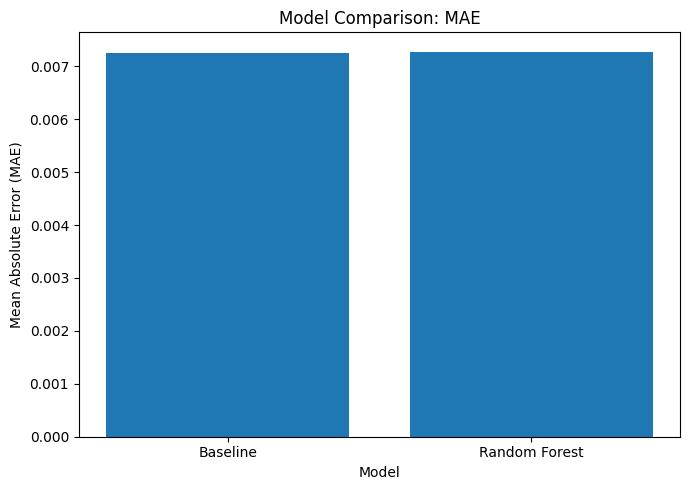

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    results_df["Model"],
    results_df["MAE"]
)

plt.title("Model Comparison: MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (MAE)")

plt.tight_layout()
plt.show()

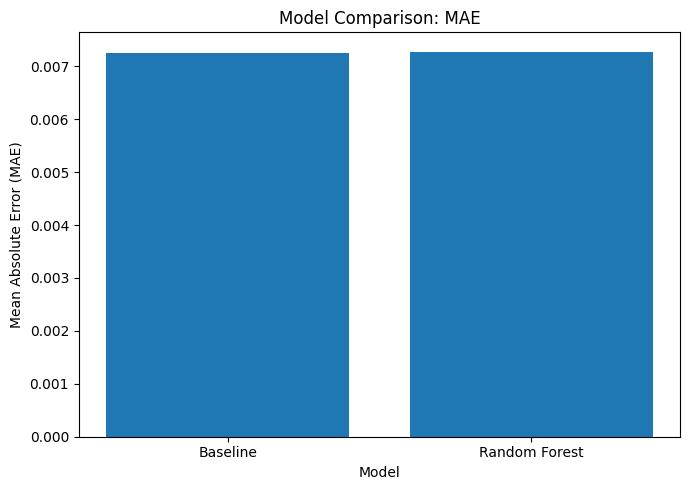

Figure saved successfully!


In [3]:
import os

os.makedirs("work/figures", exist_ok=True)

plt.figure(figsize=(7, 5))

plt.bar(
    results_df["Model"],
    results_df["MAE"]
)

plt.title("Model Comparison: MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (MAE)")

plt.tight_layout()

plt.savefig(
    "work/figures/model_vs_baseline_mae.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully!")

## 5. Limitations

*What this work cannot claim.*

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
